# Automatic Keyword Tagging for hep-ph Papers

## Motivation

Scientific literature in high-energy physics is typically annotated with a set of topical keywords that describe the main concepts, methods, and physical systems discussed in a paper. These keywords play an important role in search, categorization, and discovery, but assigning them manually is time-consuming and inherently subjective.

In this project, we study the problem of **automatic keyword tagging** for papers in the *hep-ph* (high-energy physics phenomenology) category. Given the title and abstract of a paper, the task is to predict a set of relevant keywords drawn from a fixed vocabulary. This is a **multilabel classification** problem: each paper may be associated with multiple keywords, and there is no fixed number of labels per document.

The goal of this notebook is not to achieve state-of-the-art performance, but rather to build a **transparent and well-understood baseline pipeline**, carefully evaluate it, and identify the main limitations imposed by data quality, label noise, and model assumptions. Particular emphasis is placed on proper train/validation/test separation, threshold calibration, and qualitative error analysis.

The resulting workflow provides a solid foundation for future improvements, such as richer text representations or hierarchical label structures, while remaining computationally lightweight and easy to interpret.


In [16]:
import parsing_data
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import keyword_cleanup as kc
import matplotlib.pyplot as plt
import textwrap
import joblib
from pathlib import Path

## Dataset

### Data source

The dataset is constructed using the **INSPIRE-HEP literature API**, which provides structured metadata for publications in high-energy physics. We query papers from the *hep-ph* category, excluding conference proceedings to reduce noise and improve label consistency.

Each record returned by the API includes, among other fields:
- title
- abstract
- author-provided keywords
- arXiv categories
- citation count
- publication date

Only the title, abstract, and keyword metadata are used in this project. For convenience, the papers are collected in yearly time windows. Papers are selected by citation count within each yearly window, which biases the dataset toward well-established topics and improves label reliability at the cost of reduced coverage of emerging research directions in recent years. We parse (at most) 5000 papers from each calander year, which constitutes around 70% of yearly papers in recent years. Therefore, the bias generated towards highly-cited papers is limited. 

We use the most recent year (2026) to perform a quantitative quality control for new papers without pre-existing labels.

### Dataset statistics

After preprocessing and filtering:
- Each paper is associated with **multiple keywords** (multilabel setting).
- The number of labels per paper varies significantly.
- The label distribution is highly imbalanced, with a small number of frequent keywords and a long tail of rarer ones.

The full dataset is split into **training**, **cross-validation**, and **test** sets using a fixed random seed. The cross-validation set is used exclusively for threshold tuning, while the test set is held out until final evaluation.


In [3]:
df = parsing_data.get_data(from_Year=2005,verbal=True,N=5000)

Window 2005-01-01 → 2006-01-01 | fetched 3610
Window 2006-01-01 → 2007-01-01 | fetched 3670
Window 2007-01-01 → 2008-01-01 | fetched 3727
Window 2008-01-01 → 2009-01-01 | fetched 3870
Window 2009-01-01 → 2010-01-01 | fetched 3823
Window 2010-01-01 → 2011-01-01 | fetched 3865
Window 2011-01-01 → 2012-01-01 | fetched 4269
Window 2012-01-01 → 2013-01-01 | fetched 4300
Window 2013-01-01 → 2014-01-01 | fetched 5000
Window 2014-01-01 → 2015-01-01 | fetched 5000
Window 2015-01-01 → 2016-01-01 | fetched 5000
Window 2016-01-01 → 2017-01-01 | fetched 5000
Window 2017-01-01 → 2018-01-01 | fetched 5000
Window 2018-01-01 → 2019-01-01 | fetched 5000
Window 2019-01-01 → 2020-01-01 | fetched 5000
Window 2020-01-01 → 2021-01-01 | fetched 5000
Window 2021-01-01 → 2022-01-01 | fetched 5000
Window 2022-01-01 → 2023-01-01 | fetched 5000
Window 2023-01-01 → 2024-01-01 | fetched 5000
Window 2024-01-01 → 2025-01-01 | fetched 5000


## Filtering


Keyword labels are taken directly from the INSPIRE metadata. The raw INSPIRE keywords contain substantial noise and redundancy.
To reduce extreme label sparsity and noise, we filter the keywords to avoid low-information labels according to the following categories,

1. **PACS codes**  
   Keywords matching PACS-style identifiers (e.g. `12.38.Aw`) are removed, as they encode classification metadata rather than semantic content.

2. **Physical units and numeric artifacts**  
   Keywords corresponding to physical units (e.g. `GeV`, `TeV`, `pb`, `fb`) or containing digits are removed to avoid non-semantic labels.

3. **Experiment and collaboration names**  
   Focusing on the theoretical aspect, we remove keywords referring to specific experiments or facilities (e.g. ATLAS, CMS, LHCb, Tevatron, CERN).

4. **Code-like or non-linguistic tokens**  
   Keywords dominated by non-alphabetic characters or resembling identifiers are filtered out, as they typically represent internal notation or formatting artifacts.

5. **Overly generic single-word keywords**  
   Single-token keywords with very broad meaning (e.g. *mass*, *interaction*, *model*, *distribution*, *measurement*) are removed, unless explicitly whitelisted. These labels are too generic to be predictive or informative.

6. **Redundant hierarchical parent keywords**  
   In colon-separated keyword hierarchies (e.g. `dark matter : axions`), parent keywords are removed when more specific child keywords are present. This avoids duplicate or overly coarse labels.

7. **Empty or degenerate keyword sets**  
   Papers with no remaining keywords after filtering are discarded from the dataset.

A small curated whitelist of scientifically meaningful single-word keywords (e.g. *supersymmetry*, *axion*, *higgs*, *neutrino*, *cosmology*) is retained to preserve important core concepts.

In [4]:
df,all_cleaned_keywords = kc.cleanup(df)

## Label Vocabulary

We construct our label vocabulary by selecting labels appearing above a fixed frequency threshold `MIN_FREQ`. 

&rarr; A higher frequency threshold can improve performance at the cost of losing the ability to classify smaller topics. 

&rarr; Reducing it allows for a broader classification potential, but also leads to increased rates of false labels. 

We set the threshold frequency to be 300.

Vocabulary size is : 456


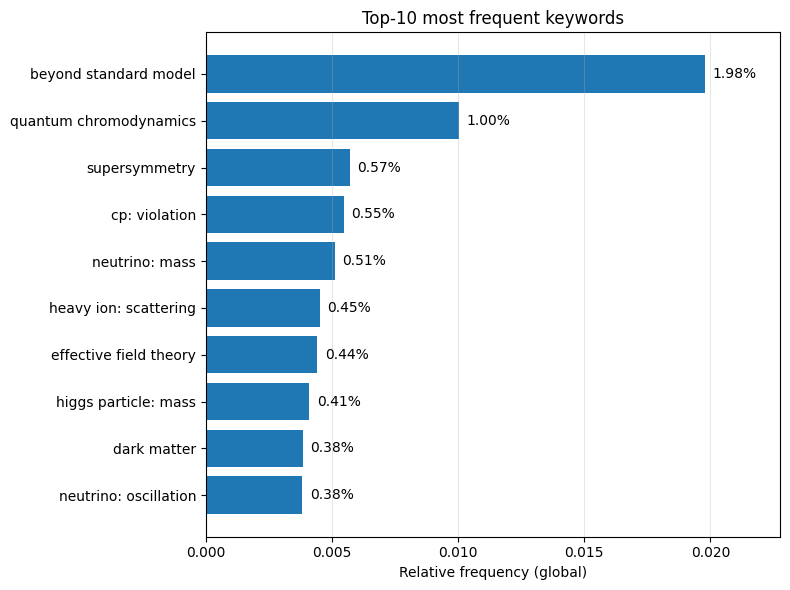

In [5]:
MIN_FREQ = 300
counts = Counter(all_cleaned_keywords)
vocab = sorted(k for k, c in counts.items() if c >= MIN_FREQ)
kw2idx = {k: i for i, k in enumerate(vocab)}
print(f'Vocabulary size is : {len(vocab)}')

N_words = 10
top = counts.most_common(N_words)

labels = [k for k, _ in top]
freqs = np.array([c for _, c in top], dtype=float)

# Normalize by TOTAL label count, not top-N
total_labels = sum(counts.values())
probs = freqs / total_labels

plt.figure(figsize=(8, 6))
bars = plt.barh(labels[::-1], probs[::-1])

plt.xlabel("Relative frequency (global)")
plt.title(f"Top-{N_words} most frequent keywords")
plt.grid(axis="x", alpha=0.3)
plt.xlim(0, max(probs) * 1.15)

# Annotate values
for bar, p in zip(bars, probs[::-1]):
    plt.text(
        bar.get_width() + 0.0003,
        bar.get_y() + bar.get_height() / 2,
        f"{100*p:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()


Figure: relative frequencies of the 10 most common keywords, normalized to the total number of keyword assignments in the dataset, illustrating the strong label imbalance and long-tailed distribution.

## Feature and label construction

This section describes how the input features `X` and target labels `Y` are constructed for the multilabel classification task.

### Text features (X)

Each paper is represented using a TF–IDF bag-of-words representation built from its title and abstract.

For every paper, the title and abstract are concatenated into a single text string. This provides a compact textual representation of the paper’s content while remaining fully interpretable.

The text is vectorized using `TfidfVectorizer` with the following design choices:

- Unigrams and bigrams (`ngram_range=(1,2)`) to capture short phrases
- English stop-word removal
- Minimum and maximum document-frequency thresholds to remove extremely rare and extremely common tokens
- A fixed maximum vocabulary size to control model complexity

This results in a sparse feature matrix `X` with shape:

- rows: number of papers
- columns: number of retained TF–IDF features

### Multilabel targets (Y)

Each paper may be associated with multiple keywords, making this a multilabel classification problem.

After keyword cleaning, a fixed label vocabulary is constructed by keeping only keywords that appear at least `MIN_FREQ` times in the dataset.

Each paper is then mapped to a binary indicator vector:

- A value of 1 indicates that a label applies to the paper
- A value of 0 indicates that it does not

Stacking these vectors produces the label matrix `Y`, where:

- rows correspond to papers
- columns correspond to labels

At the end of this step:

- `X` is a sparse TF–IDF feature matrix encoding paper content
- `Y` is a binary multilabel matrix encoding keyword assignments

The dataset is split into three disjoint subsets: 
1. A training set used to fit model parameters.
2. A cross-validation set used for threshold and hyperparameter tuning.
3. An independent test set used only for final performance evaluation.  

This separation prevents information leakage and ensures that reported test metrics reflect true generalization performance.



In [6]:
# Build feature matrix X

def make_text(df):
    return (df["title"].fillna("") + " " + df["abstract"].fillna("")).tolist()

texts = make_text(df)

idx_all = np.arange(len(df))

idx_train, idx_rest = train_test_split(idx_all, test_size=0.20, random_state=42, shuffle=True)

idx_cv, idx_test = train_test_split(idx_rest, test_size=0.50, random_state=42, shuffle=True)

df_train = df.iloc[idx_train].reset_index(drop=True)
df_cv    = df.iloc[idx_cv].reset_index(drop=True)
df_test  = df.iloc[idx_test].reset_index(drop=True)

tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    stop_words="english",
)

X_train = tfidf.fit_transform(make_text(df_train))
X_cv    = tfidf.transform(make_text(df_cv))
X_test  = tfidf.transform(make_text(df_test))

print("X_train:", X_train.shape)
print("X_cv   :", X_cv.shape)
print("X_test :", X_test.shape)


X_train: (68558, 50000)
X_cv   : (8570, 50000)
X_test : (8570, 50000)


In [7]:
def build_Y(df,kw2idx):
    rows = []
    cols = []

    for i, kws in enumerate(df["keywords_clean"]):
        for k in kws:
            if k in kw2idx:
                rows.append(i)
                cols.append(kw2idx[k])

    Y = csr_matrix(
        (np.ones(len(rows)), (rows, cols)),
        shape=(len(df), len(kw2idx)),
    )
    return Y.toarray().astype(np.int8)
Y = build_Y(df,kw2idx)

Y_train = Y[idx_train]
Y_cv    = Y[idx_cv]
Y_test  = Y[idx_test]

print("Y_train:", Y_train.shape)
print("Y_cv   :", Y_cv.shape)
print("Y_test :", Y_test.shape)


Y_train: (68558, 456)
Y_cv   : (8570, 456)
Y_test : (8570, 456)


### Regularization strength sweep (α)

To study the effect of regularization on model performance, we perform a sweep over several values of the L2 regularization parameter α in the SGD-based logistic regression classifier. For each value of α, a separate One-vs-Rest multilabel classifier is trained on the training set.

For each trained model, predicted probabilities on the cross-validation set are converted to binary label predictions using a range of decision thresholds. We then compute the micro-averaged and macro-averaged F1 scores as functions of the threshold. This allows us to assess how sensitive performance is to both the regularization strength and the classification threshold, and to identify regions of stable generalization behavior.


In [8]:
alphas = [5e-5,1e-6,5e-6,1e-7]
alphaf1vals = []
alphaf1vals_macro = []
classifiers = []
for a in alphas:

    base = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=a,
        max_iter=4000,
        tol=1e-3,
        n_jobs=-1,
    )

    clf = MultiOutputClassifier(base, n_jobs=-1)
    clf.fit(X_train, Y_train)

    classifiers.append(clf)

    # Get per-label probabilities (list of (n_samples,2) arrays)
    probs = clf.predict_proba(X_cv)

    # Convert to (n_samples, n_labels) prob of class 1
    P = np.column_stack([p[:, 1] for p in probs])

    ths = np.linspace(0.05, 0.9, 49)
    best = (-1, None)
    Y_cv_bin = (Y_cv > 0).astype(np.int8)
    f1vals = []
    f1vals_macro = []
    for thr in ths:
        Y_pred_thr = (P >= thr).astype(np.int8)
        micro_f1 = f1_score(Y_cv_bin, Y_pred_thr, average="micro")
        macro_f1 = f1_score(Y_cv_bin, Y_pred_thr, average="macro")
        f1vals.append(micro_f1)
        f1vals_macro.append(macro_f1)
    print(f'alpha={a} done..')
    alphaf1vals.append(f1vals)
    alphaf1vals_macro.append(f1vals_macro)


alpha=5e-05 done..
alpha=1e-06 done..
alpha=5e-06 done..
alpha=1e-07 done..


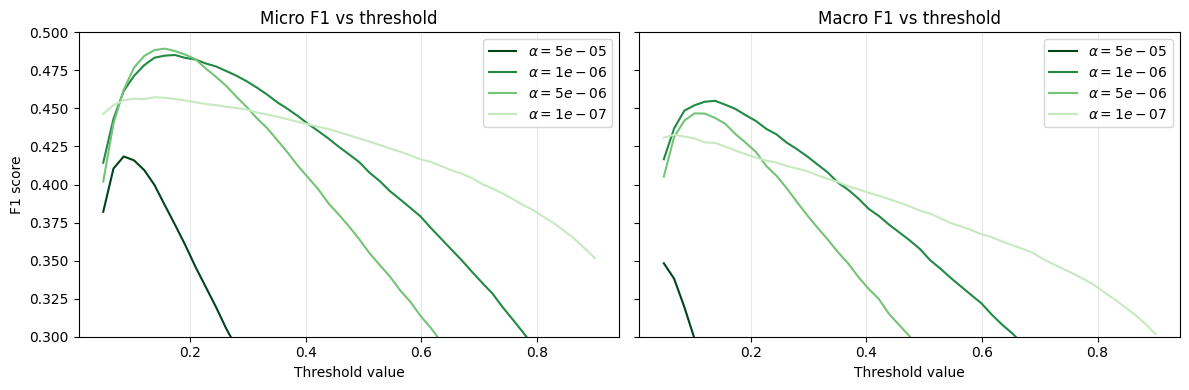

In [13]:
alphaf1vals_array       = np.array(alphaf1vals)         # micro
alphaf1vals_macro_array = np.array(alphaf1vals_macro)   # macro

colors = [plt.cm.Greens(1 - i/len(alphas)) for i in range(len(alphas))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

# --- Micro ---
ax = axes[0]
for i in range(len(alphas)):
    ax.plot(ths, alphaf1vals_array[i, :], color=colors[i], label=fr'$\alpha = {alphas[i]}$')
ax.set_title("Micro F1 vs threshold")
ax.set_xlabel("Threshold value")
ax.set_ylabel("F1 score")
ax.set_ylim(0.3, 0.5)
ax.grid(axis="x", alpha=0.3)
ax.legend()

# --- Macro ---
ax = axes[1]
for i in range(len(alphas)):
    ax.plot(ths, alphaf1vals_macro_array[i, :], color=colors[i], label=fr'$\alpha = {alphas[i]}$')
ax.set_title("Macro F1 vs threshold")
ax.set_xlabel("Threshold value")
ax.set_ylim(0.3, 0.5)
ax.grid(axis="x", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Figure: Micro- and macro-averaged F1 score as a function of the decision threshold for several values of the regularization parameter 
𝛼. Performance is primarily controlled by the threshold choice, with both metrics peaking around thresholds 0.1−0.2. 
Variations in α have a comparatively minor effect once within a reasonable range, indicating that the model is not strongly sensitive to regularization. 
As expected, macro-F1 is systematically lower than micro-F1, reflecting the difficulty of predicting less frequent keywords.

In [14]:
idx = np.argmax(alphaf1vals_array)
i, j = np.unravel_index(idx, alphaf1vals_array.shape)
alpha_optimal = alphas[i]
th_optimal = ths[j]
clf = classifiers[i]

print(f'Optimal value alpha = {alpha_optimal}')
print(f'Optimal threshold = {th_optimal:.2}')

Optimal value alpha = 5e-06
Optimal threshold = 0.16


In [ ]:
probs = clf.predict_proba(X_train)
P = np.column_stack([p[:, 1] for p in probs])
Y_pred_train = (P >= th_optimal).astype(np.int8)

probs = clf.predict_proba(X_cv)
P = np.column_stack([p[:, 1] for p in probs])
Y_pred_cv = (P >= th_optimal).astype(np.int8)

probs = clf.predict_proba(X_test)
P = np.column_stack([p[:, 1] for p in probs])
Y_pred_test = (P >= th_optimal).astype(np.int8)

Y_train_bin = (Y_train > 0).astype(np.int8)
Y_cv_bin = (Y_cv > 0).astype(np.int8)
Y_test_bin = (Y_test > 0).astype(np.int8)

micro_f1_train = f1_score(Y_train_bin, Y_pred_train, average="micro")
micro_f1_cv = f1_score(Y_cv_bin, Y_pred_cv, average="micro")
micro_f1_test = f1_score(Y_test_bin, Y_pred_test, average="micro")

macro_f1_train = f1_score(Y_train_bin, Y_pred_train, average="macro")
macro_f1_cv = f1_score(Y_cv_bin, Y_pred_cv, average="macro")
macro_f1_test = f1_score(Y_test_bin, Y_pred_test, average="macro")

print(f'The micro F1 score on training set: {micro_f1_train:.2}')
print(f'The micro F1 score on cross validation set: {micro_f1_cv:.2}')
print(f'The micro F1 score on test set: {micro_f1_test:.2}')
print('--------------------------------------------')
print(f'The macro F1 score on training set: {macro_f1_train:.2}')
print(f'The macro F1 score on cross validation set: {macro_f1_cv:.2}')
print(f'The macro F1 score on test set: {macro_f1_test:.2}')

The micro F1 score on training set: 0.72
The micro F1 score on cross validation set: 0.49
The micro F1 score on test set: 0.49
--------------------------------------------
The macro F1 score on training set: 0.71
The macro F1 score on cross validation set: 0.44
The macro F1 score on test set: 0.44


## Results 
The model achieves a micro-F1 score of 0.49 on both the cross-validation and test sets, indicating stable generalization once the decision threshold is tuned. 
The higher training F1 scores (0.72 micro, 0.71 macro) reveal a degree of overfitting, which is expected given the high-dimensional TF-IDF representation and the large number of labels. 
Macro-F1 is consistently lower than micro-F1, reflecting reduced performance on less frequent keywords and the strong label imbalance inherent to the dataset.

## Labeling unlabeled papers

We examine the most recent papers from INSPIRE-HEP which are often unlabeled. 
This provides a qualitative test of the model’s ability to assign plausible keywords to newly published papers lacking curated annotations.

In [19]:
df_check_recent = parsing_data.get_data(from_Year=2026,verbal=True,N=2000,include_this_year=True)

Window 2026-01-01 → 2026-01-27 | fetched 440


In [28]:
idx = df_check_recent.sample(n=1, random_state=None).index
df_check = df_check_recent.loc[idx]
X_check  = tfidf.transform(make_text(df_check))
probs = clf.predict_proba(X_check)
P = np.column_stack([p[:, 1] for p in probs])
Y_pred_check  = (P >= th_optimal).astype(np.int8)
check_pred_labels = [(np.array(vocab))[Y_pred_check[i].astype(bool)] for i in range(len(Y_pred_check))]

In [41]:
print(df_check.iloc[0,0])
print(100*'-')
print(textwrap.fill(df_check.iloc[0,1], width=100))
print(100*'-')
print('Predicted labels:')
for w in check_pred_labels[0]:
     print(' - '+w)

Constant-roll $β$-exponential inflation: Palatini formalism
----------------------------------------------------------------------------------------------------
In this paper, we explore the inflationary dynamics of the $β$-exponential potential model, where a
scalar field couples to quadratic $(R + R^2)$ gravity. In this model, the inflaton is the field that
determines the size of the extra dimension. We employ the Palatini formalism to derive the resulting
Einstein-frame generalized $k$-inflation effective theory, which we analyze under the assumption
that the constant-roll condition is satisfied. We scan the parameter space for inflationary
predictions, specifically the spectral index $n_s$ and the tensor-to-scalar ratio $r$, ensuring
consistency with the results from ACT DR6. The compliant regions are depicted accordingly. For a
suitable range of the model parameters, the values obtained for the inflationary observables align
with the most recent observations by the Atacama Cosmolo

## Summary

In this project, we developed a multilabel text classification pipeline for automatic keyword tagging of *hep-ph* papers using INSPIRE metadata. After cleaning keywords, a reduced and well-behaved label vocabulary was constructed by removing rare, generic, and non-semantic labels.

Text features were extracted from concatenated titles and abstracts using a TF–IDF representation, and labels were modeled with a One-vs-Rest logistic regression classifier trained via stochastic gradient descent. Model performance was evaluated using a strict train / cross-validation / test split, with decision thresholds tuned on the validation set.

The final model achieves a micro-F1 score of approximately **0.49** and a macro-F1 score of **0.44** on the held-out test set, indicating strong performance on frequent labels and reasonable generalization across the label space. Threshold tuning significantly improves performance over naive baselines, while regularization strength has a relatively mild effect.

Overall, this establishes a solid, interpretable baseline for automatic keyword tagging in high-energy phenomenology. 
Future improvements could come from richer text representations that capture semantic similarity, introducing structure among related keywords, and better calibration of per-label prediction thresholds.
